# Mamba 実践的学習教材

このノートブックでは、Mambaのアーキテクチャを小さな実装で分解しながら学びます。SSMが未学習の場合は、先に `ssm_foundation_practical_tutorial.ipynb` を実行してください。

学習ステップ:

1. Transformer/RNN/SSM/Mambaの計算構造を比較する
2. 選択的SSM(selective SSM)のスキャン計算をNumPyで実装する
3. Mambaブロックの部品をPyTorchで組み立てる
4. 小さな合成タスクで、入力に応じて覚える動作を確認する
5. アーキテクチャ上の要点を自分の言葉で説明できるようにする

主な参考資料:

- Gu, Dao, *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*, 2023: https://arxiv.org/abs/2312.00752
- state-spaces/mamba official repository: https://github.com/state-spaces/mamba
- Gu et al., *Efficiently Modeling Long Sequences with Structured State Spaces*, 2021: https://arxiv.org/abs/2111.00396

## 0. 依存関係

前半の選択的SSMは `numpy` だけで動きます。後半のMambaブロックと学習実験には `torch` を使います。

```bash
pip install torch numpy matplotlib
```

この教材はMamba公式CUDAカーネルを使わず、理解用の小さな実装にしています。そのため長系列での速度は公式実装とは異なります。

In [33]:
import math
import time
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
except Exception as e:
    HAS_TORCH = False
    TORCH_IMPORT_ERROR = e

np.set_printoptions(precision=3, suppress=True)
print('numpy:', np.__version__)
print('matplotlib:', 'available' if HAS_MPL else 'not available')
print('torch:', torch.__version__ if HAS_TORCH else f'not available: {TORCH_IMPORT_ERROR}')

numpy: 2.4.6
matplotlib: available
torch: 2.6.0+cu124


## 使われている技術

ここでは、Mambaの実装中に登場する汎用的な技術や処理を個別に整理します。以降、新しい疑問が出たときはこのセクションに説明と最小実装を追加します。

### 技術1: CausalConv1D（因果1次元畳み込み）

CausalConv1Dは、時刻 $t$ の出力を計算するときに、**現在 $t$ と過去の入力だけ**を使う1次元畳み込みです。未来の入力 $X_{t+1}, X_{t+2}, \ldots$ は参照しないため、系列を左から右へ生成する場合にも情報漏洩が起きません。

カーネル幅を $K$ とすると、チャネル $c$ の出力は次のように計算されます。

$$V_{t,c} = b_c + \sum_{k=0}^{K-1} a_{c,k} X_{t-k,c}$$

系列の先頭より前は $X_{t,c}=0$（$t<0$）とします。例えば $K=3$ なら、$V_t$ は $X_{t-2}, X_{t-1}, X_t$ から計算され、$X_{t+1}$ は使いません。

この教材では `groups=channels` を指定する **depthwise convolution** を使います。各チャネルが独自のカーネルを持ち、畳み込み中はチャネル同士を混ぜません。チャネル間の混合は前後のLinear層が担当します。

PyTorchの `Conv1d` に `padding=K-1` を指定すると両端にゼロが追加され、出力は入力より長くなります。その出力の先頭 $L$ 個だけを残すと、各時刻が参照する範囲は $t-K+1$ から $t$ までになり、因果性を満たします。なお、PyTorch内部の重み配列は `[最も古い入力, ..., 現在の入力]` の順に対応します。


In [34]:
def causal_depthwise_conv1d(x, conv1d):
    """(batch, length, channels)の系列に因果depthwise畳み込みを適用する。"""
    length = x.shape[1]
    # Conv1dが要求する(batch, channels, length)へ並べ替えます。
    x_channels_first = x.transpose(1, 2)

    # paddingで増えた末尾を捨て、未来を参照しない先頭L時刻だけを残します。
    y = conv1d(x_channels_first)[:, :, :length]
    return y.transpose(1, 2)


if HAS_TORCH:
    # 1チャネル、K=3の小さな例で、実装結果と手計算を比較します。
    example_x = torch.tensor([[[1.0], [2.0], [3.0], [4.0]]])
    example_conv = nn.Conv1d(1, 1, kernel_size=3, groups=1, padding=2, bias=False)
    with torch.no_grad():
        # 重みは順に x[t-2], x[t-1], x[t] へ掛かります。
        example_conv.weight[:] = torch.tensor([[[0.1, 0.2, 0.7]]])

    example_y = causal_depthwise_conv1d(example_x, example_conv)
    # t=2: 0.1*1 + 0.2*2 + 0.7*3 = 2.6
    print('input :', example_x.flatten().tolist())
    print('output:', example_y.flatten().tolist())
else:
    print('PyTorchがないため、CausalConv1Dの実装例をスキップします。')


input : [1.0, 2.0, 3.0, 4.0]
output: [0.699999988079071, 1.600000023841858, 2.5999999046325684, 3.5999999046325684]


### 技術2: SiLU（Sigmoid Linear Unit）

SiLUは、入力 $x$ にその入力自身から作ったSigmoidゲートを掛ける活性化関数です。Swish（パラメータ $\beta=1$）とも呼ばれます。

$$\sigma(x)=\frac{1}{1+e^{-x}}$$

$$\mathrm{SiLU}(x)=x\,\sigma(x)=\frac{x}{1+e^{-x}}$$

$\sigma(x)$ は0から1の範囲で、入力 $x$ をどの程度通すかを決めます。そのためSiLUは次のように振る舞います。

- $x$ が大きな正の値: $\sigma(x)\simeq1$ なので、$\mathrm{SiLU}(x)\simeq x$
- $x=0$: $\sigma(0)=0.5$ ですが、$x$ を掛けるので $\mathrm{SiLU}(0)=0$
- $x$ が負の値: 小さな負の値を残し、$x\to-\infty$ では0へ近づく

ReLUのように負の入力をすべて0にせず、0付近も滑らかにつながっています。また、負側に浅い谷があるため、SiLU自体は単調増加ではありません。

このMamba実装では、`scan_x = F.silu(conv_out)` によって畳み込み後の特徴を滑らかに選別し、`ssm_out * F.silu(z_branch)` によってSSM出力を入力依存で調整します。後者の値は0から1に限定されないため、SSM出力を抑えるだけでなく、強めたり符号を反転したりすることもできます。


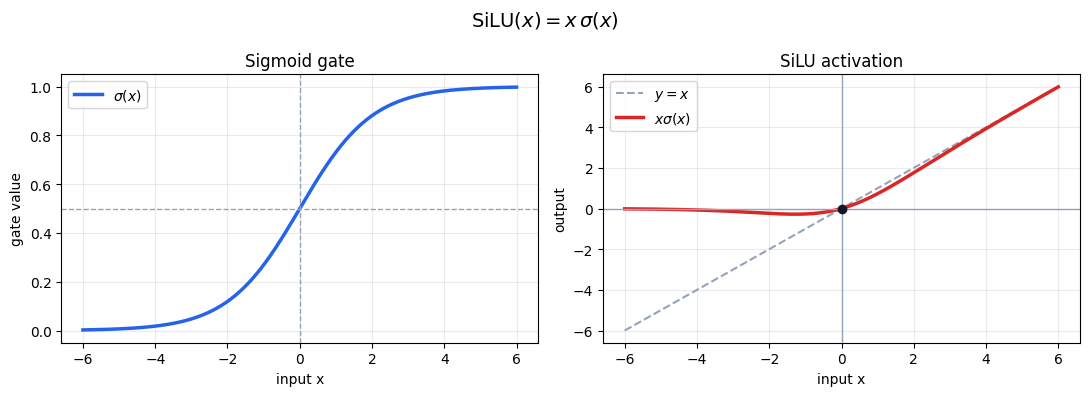

In [35]:
def sigmoid_numpy(x):
    return 1.0 / (1.0 + np.exp(-x))


def silu_numpy(x):
    # 入力そのものに、Sigmoidで求めた通過率を掛けます。
    return x * sigmoid_numpy(x)


if HAS_MPL:
    x = np.linspace(-6.0, 6.0, 500)
    gate = sigmoid_numpy(x)
    silu = silu_numpy(x)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # 左図: 入力から作られるSigmoidゲート（通過率）を示します。
    axes[0].plot(x, gate, color='#2563eb', linewidth=2.5, label=r'$\sigma(x)$')
    axes[0].axhline(0.5, color='#94a3b8', linestyle='--', linewidth=1)
    axes[0].axvline(0.0, color='#94a3b8', linestyle='--', linewidth=1)
    axes[0].set_title('Sigmoid gate')
    axes[0].set_xlabel('input x')
    axes[0].set_ylabel('gate value')
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # 右図: xにゲートを掛けたSiLUと、比較用の入力y=xを描きます。
    axes[1].plot(x, x, color='#94a3b8', linestyle='--', linewidth=1.5, label=r'$y=x$')
    axes[1].plot(x, silu, color='#dc2626', linewidth=2.5, label=r'$x\sigma(x)$')
    axes[1].scatter([0], [0], color='#111827', zorder=3)
    axes[1].axhline(0.0, color='#94a3b8', linewidth=1)
    axes[1].axvline(0.0, color='#94a3b8', linewidth=1)
    axes[1].set_title('SiLU activation')
    axes[1].set_xlabel('input x')
    axes[1].set_ylabel('output')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    fig.suptitle(r'$\mathrm{SiLU}(x)=x\,\sigma(x)$', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Matplotlibがないため、SiLUの図をスキップします。')


### 技術3: Softplus

Softplusは、任意の実数を**滑らかな正の値**へ変換する活性化関数です。

$$\mathrm{softplus}(x)=\log(1+e^x)$$

入力が十分大きいときは $\mathrm{softplus}(x)\simeq x$、十分小さいときは0へ近づきます。そのため、$\max(0,x)$ で表されるReLUを滑らかにした関数とみなせます。ただしSoftplusの出力は数学的には常に0より大きく、0の位置にも折れ曲がりがありません。

導関数はSigmoidになります。

$$\frac{d}{dx}\mathrm{softplus}(x)=\sigma(x)$$

#### Mambaで使う理由

Mambaでは、Linear層が出力した制約のない値を `delta = F.softplus(...)` に通します。`delta` は連続時間SSMを離散化するときの時間幅なので、正である必要があります。

この教材では $A=-\exp(A_{log})<0$ としているため、$\Delta_t>0$ なら次式の状態遷移係数は0から1の範囲になり、過去の状態を減衰させます。

$$\bar{A}_t=\exp(\Delta_t A), \qquad 0<\bar{A}_t<1$$

小さな $\Delta_t$ では $\bar{A}_t$ が1に近くなって過去を残しやすく、大きな $\Delta_t$ では0に近づいて過去を強く減衰させます。Softplusは、この時間幅を正に保ちながら勾配で学習できるようにしています。

なお、式をそのまま `log(1 + exp(x))` と実装すると、大きな正の $x$ で `exp(x)` がオーバーフローする可能性があります。次のコードでは、同値な式を使って数値的に安定させています。


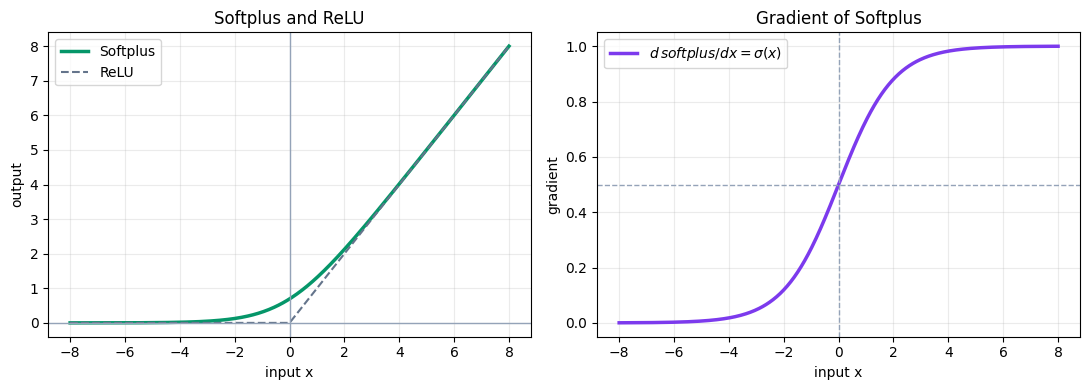

In [36]:
def softplus_numpy(x):
    # log(1 + exp(x))と同値ですが、大きな正のxでもオーバーフローしにくい形です。
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)


if HAS_MPL:
    x = np.linspace(-8.0, 8.0, 500)
    softplus_y = softplus_numpy(x)
    relu_y = np.maximum(x, 0)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # 左図: SoftplusはReLUの折れ曲がりを滑らかにした形になります。
    axes[0].plot(x, softplus_y, color='#059669', linewidth=2.5, label='Softplus')
    axes[0].plot(x, relu_y, color='#64748b', linestyle='--', linewidth=1.5, label='ReLU')
    axes[0].axhline(0.0, color='#94a3b8', linewidth=1)
    axes[0].axvline(0.0, color='#94a3b8', linewidth=1)
    axes[0].set_title('Softplus and ReLU')
    axes[0].set_xlabel('input x')
    axes[0].set_ylabel('output')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # 右図: Softplusの傾きはSigmoidで、0から1へ滑らかに変化します。
    axes[1].plot(x, sigmoid_numpy(x), color='#7c3aed', linewidth=2.5, label=r'$d\,softplus/dx=\sigma(x)$')
    axes[1].axhline(0.5, color='#94a3b8', linestyle='--', linewidth=1)
    axes[1].axvline(0.0, color='#94a3b8', linestyle='--', linewidth=1)
    axes[1].set_title('Gradient of Softplus')
    axes[1].set_xlabel('input x')
    axes[1].set_ylabel('gradient')
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print('Matplotlibがないため、Softplusの図をスキップします。')


### 技術4: RMSNorm（RMSによる正規化）

RMSは **Root Mean Square（二乗平均平方根）** の略です。RMSNormは、各トークンの特徴ベクトル $x\in\mathbb{R}^d$ の大きさをRMSで割って揃える正規化です。

$$\mathrm{RMS}(x)=\sqrt{\frac{1}{d}\sum_{i=1}^{d}x_i^2+\varepsilon}$$

$$\mathrm{RMSNorm}(x)_i=g_i\frac{x_i}{\mathrm{RMS}(x)}$$

$\varepsilon$ は0除算を防ぐ小さな定数、$g_i$ は学習可能なチャネルごとの重みです。正規化直後のベクトルはRMSがほぼ1になり、$g$ によってモデルが必要な大きさへ再調整できます。

例えば $x=[1,2,-2]$ なら、$\mathrm{RMS}(x)=\sqrt{(1^2+2^2+(-2)^2)/3}=\sqrt{3}$ なので、$g=[1,1,1]$ のとき出力はおよそ $[0.577,1.155,-1.155]$ です。すべての要素を同じRMSで割るため、要素同士の比率と符号は保たれます。

#### なぜLayerNormではなくRMSNormなのか

LayerNormは特徴の平均を引いてから分散で割るため、出力の平均を0付近にします。一方、RMSNormは平均を引かず、二乗平均だけで大きさを揃えます。

$$\mathrm{LayerNorm}(x)=\gamma\frac{x-\mathrm{mean}(x)}{\sqrt{\mathrm{var}(x)+\varepsilon}}+\beta$$

LayerNormは、入力全体の大きさが変わる **再スケーリング** と、全要素に同じ値が加わる **再中心化** の両方を打ち消します。RMSNormは再スケーリングだけを打ち消し、平均成分は残します。

- LayerNorm: $x\mapsto ax+b\mathbf{1}$ のスケール $a$ とシフト $b$ の影響を取り除く
- RMSNorm: $x\mapsto ax$ のスケール $a$ の影響だけを取り除く

RMSNormを選ぶ考え方は、深い残差モデルの学習安定化には特徴ベクトルの大きさを揃えることが主に重要で、平均を毎層0へ戻す操作は必ずしも必要ない、というものです。平均を引かないため、入力が持つ平均成分も後続層が利用できます。ただし、その平均成分が常に有用という意味ではなく、どちらが適するかはモデルと学習条件に依存します。

> **結論**
>
> RMSNormは単に処理を省くためだけの手法ではありません。学習を安定させるスケール正規化を残しながら、LayerNormの平均を引く制約を外した設計です。その上で、平均・分散を計算するLayerNormより演算が単純という実装上の利点もあります。最適化されたGPUカーネルでは、実際の速度差が小さい場合もあります。

RMSNormでも十分な学習安定性と精度が得られる場合、より単純なRMSNormを選ぶ利点があります。一方、特徴の平均のずれを明示的に取り除きたい場合や、既存モデルがLayerNorm前提で調整されている場合はLayerNormが適することがあります。RMSNormが常にLayerNormより優れているわけではありません。

#### RMSNormの効果

主な効果は、トークンごとの特徴ベクトルの大きさを揃えることです。入力全体が大きな定数 $c>0$ 倍になっても、$\varepsilon$ の影響を無視すれば正規化後はほぼ同じになります。

$$\mathrm{RMSNorm}(c x)\simeq\mathrm{RMSNorm}(x)$$

このスケールに対する安定性により、次の層へ渡る値や勾配が極端に大きくなったり小さくなったりするのを抑え、深いモデルを学習しやすくします。一方で、各チャネルの符号や相対的な比率は保ち、学習可能な重み $g_i$ によって必要なチャネルを再び強調できます。

RMSNormは系列内のトークン同士を混ぜません。`x.shape == (batch, length, d_model)` の最後の特徴次元 `d_model` だけを使い、各トークンを独立に正規化します。そのため未来のトークン情報が混ざることもありません。

#### このMambaモデルでRMSNormを使う理由

まず、MambaのSSM理論がRMSNormを必須としているわけではありません。LayerNormなど別の正規化を使う設計も可能です。この教材では、各層で次のPre-Norm型の残差接続を安定させるためにRMSNormを使います。

$$x_{next}=x+\mathrm{MambaBlock}(\mathrm{RMSNorm}(x))$$

残差経路の $x$ は直接残しながら、Mambaブロックへ入る特徴だけを一定の大きさに揃えます。これにより、層を重ねても各ブロックが受け取る入力スケールが極端に変化しにくくなります。Mambaブロックでは入力から `Delta, B, C` や `z_branch` のゲートを作るため、それらのLinear層へ入る値の大きさを安定させる意味もあります。

ここでLayerNormではなくRMSNormを使う理由は、平均を0へ戻さなくても入力スケールを安定させる目的を満たせることと、処理が単純であることです。RMSNormが系列情報を記憶したり選択したりするわけではありません。系列方向の処理はMambaブロックが担当し、RMSNormはその前段で数値スケールを整える役割です。

#### 使用される場面

RMSNormは、Transformer系LLM、MambaなどのSSMモデル、その他の深い残差型ニューラルネットワークでよく使われます。特に、次のような場面に向いています。

- 多数のブロックを積み重ね、層ごとの特徴量の大きさを安定させたい場合
- Pre-Norm型の残差接続を使う場合
- バッチ全体の統計量に依存せず、各トークンを独立に正規化したい場合
- 平均を0にする必要性が低く、スケール正規化だけを使いたい場合


In [37]:
def rms_norm_numpy(x, weight=None, eps=1e-6):
    # 各トークンについて、最後の特徴次元のRMSを計算します。
    rms = np.sqrt(np.mean(x ** 2, axis=-1, keepdims=True) + eps)
    normalized = x / rms

    # 実際のRMSNormでは、チャネルごとの学習可能な重みを掛けます。
    if weight is not None:
        normalized = normalized * weight
    return normalized


example_x = np.array([1.0, 2.0, -2.0])
example_y = rms_norm_numpy(example_x, weight=np.ones(3))
scaled_y = rms_norm_numpy(100.0 * example_x, weight=np.ones(3))
print('input:', example_x)
print('input RMS:', np.sqrt(np.mean(example_x ** 2)))
print('RMSNorm output:', np.round(example_y, 3))
print('output RMS:', np.sqrt(np.mean(example_y ** 2)))
print('output from 100x input:', np.round(scaled_y, 3))
print('almost scale invariant:', np.allclose(example_y, scaled_y, atol=1e-5))


input: [ 1.  2. -2.]
input RMS: 1.7320508075688772
RMSNorm output: [ 0.577  1.155 -1.155]
output RMS: 0.9999998333333749
output from 100x input: [ 0.577  1.155 -1.155]
almost scale invariant: True


## 1. Mambaの全体像

Mambaは、注意機構を中心にしたTransformerではなく、選択的SSMを中心にした系列モデルです。論文上の重要点は次の3つです。

- **Selection**: `Delta, B, C` を入力から作り、トークンごとに状態更新を変える
- **Hardware-aware scan**: 時変SSMをGPUで効率よく計算するため、並列スキャン・カーネル融合・再計算を使う
- **Simplified block**: attentionや明示的なMLPブロックを置かず、SSM中心のブロックにまとめる

この教材では、速度最適化ではなくアーキテクチャ理解に集中します。次に、ブロック内の2つの経路を数式で整理し、その後にデータの流れを図として描きます。


### 1.1 Mambaブロックを数式で追う

入力系列を $X \in \mathbb{R}^{L \times d_{model}}$ とします。Mambaブロックでは、まず線形変換で特徴次元を広げ、2つの経路に分けます。

$$[X_{branch}, Z_{branch}] = X W_{in} + b_{in}$$

ここで、$X_{branch}$ は選択的SSMに入る本体の経路、$Z_{branch}$ は最後にSSM出力を調整するゲート経路です。`z_branch` は`in_proj` で入力 $X$ から作られるもう一方の分岐です。

次に、$X_{branch}$ に短い因果畳み込みをかけ、近傍トークンの局所情報を混ぜます。CausalConv1Dの計算方法と最小実装は、前の「使われている技術」セクションを参照してください。

$$U = \mathrm{SiLU}(\mathrm{CausalConv1D}(X_{branch}))$$

この $U$ から、時刻ごとに変わるSSMパラメータを作ります。

$$[R_\Delta, B, C] = U W_x$$

$$\Delta = \mathrm{softplus}(R_\Delta W_\Delta + b_\Delta)$$

<details>
<summary><strong>補足: なぜLinearを2回通すのか</strong></summary>

> ここで、$R_\Delta=UW_R$ と書けば、Deltaを作る部分は次のようになります。
>
> $$S_\Delta=UW_RW_\Delta+b_\Delta$$
>
> 間に活性化関数がないため、2つの重みは数学的には1つにまとめられます。
>
> $$W_{eff}=W_RW_\Delta, \qquad S_\Delta=UW_{eff}+b_\Delta$$
>
> それでも2段に分ける理由は、$W_{eff}$ を**低ランク行列に制限するため**です。$W_R$ が $d_{inner}\times dt\_rank$、$W_\Delta$ が $dt\_rank\times d_{inner}$ なら、積のランクは次の上限を持ちます。
>
> $$\mathrm{rank}(W_{eff})\leq dt\_rank$$
>
> 直接変換では重みが $d_{inner}^2$ 個必要ですが、低ランク分解ではDelta生成に関する重みが $2d_{inner}\,dt\_rank$ 個になります。したがって、$dt\_rank$ が $d_{inner}$ より十分小さければ計算量とパラメータ数を削減できます。その代わり、任意の $W_{eff}$ を表現できるわけではなく、Deltaの変化を少数の共通パターンの組み合わせに制限します。
>
> 例えば、この教材の `d_model=16, expand=2, dt_rank=4` では $d_{inner}=32$ です。直接変換の重みは $32^2=1024$ 個ですが、低ランク分解部分は $32\times4+4\times32=256$ 個です。
>
> 実装では `x_proj` が $R_\Delta,B,C$ をまとめて作り、そのうち `dt_raw` が $R_\Delta$ に対応します。`dt_proj` が $W_\Delta,b_\Delta$ による2段目のLinearです。
>
> ```python
> params = self.x_proj(u)
> dt_raw, B, C = torch.split(params, [...], dim=-1)  # dt_raw = R_Delta
> delta_pre = self.dt_proj(dt_raw)                    # R_Delta W_Delta + b_Delta
> delta = F.softplus(delta_pre)                       # 正の時間幅にする
> ```
>
> つまり、2回のLinearは表現を増やすためではなく、Delta生成を小さな `dt_rank` を通る低ランク変換として実装するためにあります。
</details>

<details>
<summary><strong>$\Delta$（Delta）とは</strong></summary>

> $\Delta$ は、連続時間で定義されたSSMを離散的なトークン列へ変換するときの**実効的な時間幅（step size）**です。通常のSSMでは共通のスカラー値にできますが、Mambaでは入力 $U_t$ から時刻・チャネルごとの $\Delta_{t,c}$ を作ります。
>
> $$\Delta_t=\mathrm{softplus}(R_{\Delta,t}W_\Delta+b_\Delta)>0$$
>
> この教材では `delta.shape == (batch, length, d_inner)` です。つまり、同じトークンでも内部チャネル $c$ ごとに異なる時間幅を持ちます。Softplusを通すのは、時間幅を正に制約するためです。
>
> **なぜ $\Delta$ は `d_inner` 個あるのか**
>
> チャネルごとに、過去の情報をどれだけ維持するかを変えるためです。小さな $\Delta_{t,c}$ のチャネルは過去を長く保持し、大きな $\Delta_{t,c}$ のチャネルは過去を強く減衰させて現在の入力へ素早く反応します。$\Delta_t$ が1つのスカラーだけでは、全チャネルの維持量が同じになってしまいます。
>
> 連続時間の状態方程式 $dh/dt=Ah+Bu$ を、トークン位置 $t$ で $\Delta_t$ だけ進めると考えます。状態遷移は次のように離散化されます。
>
> $$\bar A_t=\exp(\Delta_t A)$$
>
> この実装では $A=-\exp(A_{log})<0$ なので、1つの状態成分を $A=-\lambda$（$\lambda>0$）と書くと、過去の状態に掛かる係数は次のようになります。
>
> $$\bar A_t=\exp(-\lambda\Delta_t)$$
>
> - **小さい $\Delta_t$**: $\bar A_t$ は1に近く、過去の状態をほぼ残します。同時に、この教材の $\Delta_t B_tU_t$ も小さくなるため、現在の入力による更新も穏やかです。
> - **大きい $\Delta_t$**: $\bar A_t$ は0に近づき、過去の状態を強く減衰させます。現在の入力による状態更新は大きくなりやすくなります。
>
> 例えば $A=-1$ なら、$\Delta=0.1$ のとき過去の状態の保持率は $e^{-0.1}\simeq0.905$、$\Delta=1.0$ なら $e^{-1}\simeq0.368$ です。したがって、$\Delta$ は各入力を見て「状態をゆっくり変えるか、大きく更新するか」を調整する時間スケールと解釈できます。
>
> ただし、$\Delta_t$ はattention weightのようなトークン重要度ではありません。実際の書き込み内容は $B_t$、読み出し内容は $C_t$、状態ごとの減衰速度は $A$ も共同で決めます。また、教材の $\bar B_tU_t\approx\Delta_tB_tU_t$ は理解用の簡略化であり、$A$ の指数関数を使う厳密な離散化とは異なります。
</details>

選択的SSMでは、各時刻 $t$ で入力依存の $\Delta_t, B_t, C_t$ を使って状態を更新します。

$$\bar{A}_t = \exp(\Delta_t A)$$

$$h_t = \bar{A}_t h_{t-1} + \Delta_t B_t U_t$$

$$Y^{ssm}_t = C_t h_t + D U_t$$

最後に、入力から作った $Z_{branch}$ をゲート係数へ変換し、SSM出力の各要素をどれだけ通すかを調整します。

$$G = \mathrm{SiLU}(Z_{branch})$$

$$Y = W_{out}(Y^{ssm} \odot G) + b_{out}$$

<details>
<summary><strong>$Z_{branch}$ のゲート、残差接続、次単語予測の違い</strong></summary>

> ここでの $X$ や $Y^{ssm}$ は単語そのものではなく、各トークン位置が持つ**隠れ特徴ベクトル**です。$Y^{ssm}$ は次の単語を直接表しているわけではありません。
>
> `x_branch` と `z_branch` は同じ入力 $X$ から作られますが、異なる学習済み重みを使う別の値です。
>
> $$X_{branch}=XW_x+b_x, \qquad Z_{branch}=XW_z+b_z$$
>
> $Y^{ssm}_t$ は `x_branch` の現在までの系列からSSMが作る特徴、$G_t$ は `z_branch` から作る要素ごとの係数です。形状は同じでも、同じ値同士を掛けているわけではありません。
>
> $$Y^{ssm}_t=\mathrm{SSM}(X_{branch,1:t}), \qquad G_t=\mathrm{SiLU}(Z_{branch,t})$$
>
> $$H^{block}_t=W_{out}(Y^{ssm}_t\odot G_t)+b_{out}$$
>
> 例えば $Y^{ssm}$ のある要素が2でも、ゲートが0.1なら0.2、1.5なら3になります。これは、どの隠れ特徴を現在の入力に応じて通すかを決める処理です。なお、選択的SSM自体も $\Delta,B,C$ によって既に入力依存であり、`z_branch` はさらに出力側で行う局所的なゲートです。
>
> 残差接続は別にあり、$H_t=X_t+H^{block}_t$ と入力特徴を**足し算**で残します。教材では `x + mamba(norm(x))` がこの処理です。
>
> 次単語予測は、複数のMambaブロックを通した最終的な隠れ特徴 $H^{final}_t$ を、最後の `lm_head` で語彙数次元のlogitへ変換して行います。
>
> $$\mathrm{logits}_t=W_{vocab}H^{final}_t+b_{vocab}$$
>
> $$p(x_{t+1}\mid x_{1:t})=\mathrm{softmax}(\mathrm{logits}_t)$$
>
> したがって、`ssm_out * gate` は単語同士の掛け算ではなく、次単語予測より前にある2種類の隠れ特徴を使ったゲート処理です。
</details>

つまり、`x_branch` は「何を系列方向に伝えるか」を作る経路、`z_branch` は「SSM出力をどれだけ通すか」を決める経路です。この2つはどちらも同じ入力から作られ、最後に掛け算で合流します。


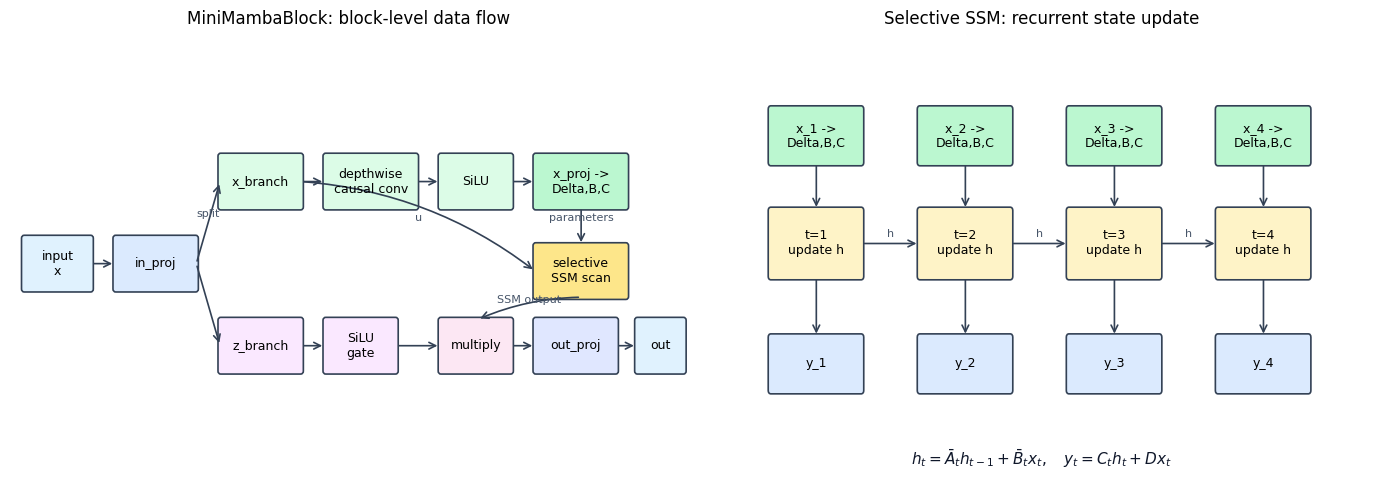

In [38]:
# Mambaのアーキテクチャを図で確認するための補助関数です。
# 実装本体とは独立しており、ブロック内のテンソルの流れを視覚化します。
if HAS_MPL:
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

    def draw_box(ax, xy, width, height, text, facecolor='#f8f9fb', edgecolor='#334155'):
        x, y = xy
        box = FancyBboxPatch(
            (x, y), width, height,
            boxstyle='round,pad=0.03,rounding_size=0.04',
            linewidth=1.2, edgecolor=edgecolor, facecolor=facecolor
        )
        ax.add_patch(box)
        ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', fontsize=9)
        return box

    def draw_arrow(ax, start, end, text=None, connectionstyle='arc3,rad=0.0'):
        arrow = FancyArrowPatch(
            start, end, arrowstyle='->', mutation_scale=12, linewidth=1.2,
            color='#334155', connectionstyle=connectionstyle
        )
        ax.add_patch(arrow)
        if text:
            mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
            ax.text(mx, my + 0.05, text, ha='center', va='bottom', fontsize=8, color='#475569')

    fig, (ax_block, ax_scan) = plt.subplots(1, 2, figsize=(14, 5))

    # 左図: 1つのMambaブロックの中で、入力が2つの経路に分かれて再合流する様子。
    ax_block.set_title('MiniMambaBlock: block-level data flow', fontsize=12)
    ax_block.set_xlim(0, 10)
    ax_block.set_ylim(0, 6)
    ax_block.axis('off')

    draw_box(ax_block, (0.2, 2.55), 1.0, 0.7, 'input\nx', '#e0f2fe')
    draw_box(ax_block, (1.55, 2.55), 1.2, 0.7, 'in_proj', '#dbeafe')
    draw_box(ax_block, (3.1, 3.65), 1.2, 0.7, 'x_branch', '#dcfce7')
    draw_box(ax_block, (4.65, 3.65), 1.35, 0.7, 'depthwise\ncausal conv', '#dcfce7')
    draw_box(ax_block, (6.35, 3.65), 1.05, 0.7, 'SiLU', '#dcfce7')
    draw_box(ax_block, (7.75, 3.65), 1.35, 0.7, 'x_proj ->\nDelta,B,C', '#bbf7d0')
    draw_box(ax_block, (7.75, 2.45), 1.35, 0.7, 'selective\nSSM scan', '#fde68a')
    draw_box(ax_block, (3.1, 1.45), 1.2, 0.7, 'z_branch', '#fae8ff')
    draw_box(ax_block, (4.65, 1.45), 1.05, 0.7, 'SiLU\ngate', '#fae8ff')
    draw_box(ax_block, (6.35, 1.45), 1.05, 0.7, 'multiply', '#fce7f3')
    draw_box(ax_block, (7.75, 1.45), 1.2, 0.7, 'out_proj', '#e0e7ff')
    draw_box(ax_block, (9.25, 1.45), 0.7, 0.7, 'out', '#e0f2fe')

    draw_arrow(ax_block, (1.2, 2.9), (1.55, 2.9))
    draw_arrow(ax_block, (2.75, 2.9), (3.1, 4.0), 'split')
    draw_arrow(ax_block, (2.75, 2.9), (3.1, 1.8))
    draw_arrow(ax_block, (4.3, 4.0), (4.65, 4.0))
    draw_arrow(ax_block, (6.0, 4.0), (6.35, 4.0))
    draw_arrow(ax_block, (7.4, 4.0), (7.75, 4.0))
    draw_arrow(ax_block, (8.43, 3.65), (8.43, 3.15), 'parameters')
    draw_arrow(ax_block, (4.3, 4.0), (7.75, 2.8), 'u', 'arc3,rad=-0.15')
    draw_arrow(ax_block, (4.3, 1.8), (4.65, 1.8))
    draw_arrow(ax_block, (5.7, 1.8), (6.35, 1.8))
    draw_arrow(ax_block, (8.43, 2.45), (6.9, 2.15), 'SSM output', 'arc3,rad=0.1')
    draw_arrow(ax_block, (7.4, 1.8), (7.75, 1.8))
    draw_arrow(ax_block, (8.95, 1.8), (9.25, 1.8))

    # 右図: 選択的SSMは、各時刻で入力依存のDelta/B/Cを使って状態hを更新する。
    ax_scan.set_title('Selective SSM: recurrent state update', fontsize=12)
    ax_scan.set_xlim(0, 10)
    ax_scan.set_ylim(0, 5.3)
    ax_scan.axis('off')

    xs = [1.0, 3.2, 5.4, 7.6]
    for idx, x0 in enumerate(xs, start=1):
        draw_box(ax_scan, (x0, 2.4), 1.35, 0.8, f't={idx}\nupdate h', '#fef3c7')
        draw_box(ax_scan, (x0, 3.75), 1.35, 0.65, f'x_{idx} ->\nDelta,B,C', '#bbf7d0')
        draw_box(ax_scan, (x0, 1.05), 1.35, 0.65, f'y_{idx}', '#dbeafe')
        draw_arrow(ax_scan, (x0 + 0.68, 3.75), (x0 + 0.68, 3.2))
        draw_arrow(ax_scan, (x0 + 0.68, 2.4), (x0 + 0.68, 1.7))
    for x0, x1 in zip(xs[:-1], xs[1:]):
        draw_arrow(ax_scan, (x0 + 1.35, 2.8), (x1, 2.8), 'h')
    ax_scan.text(5.0, 0.25, r'$h_t = \bar{A}_t h_{t-1} + \bar{B}_t x_t,\quad y_t = C_t h_t + D x_t$',
                 ha='center', va='center', fontsize=11, color='#0f172a')

    plt.tight_layout()
    plt.show()
else:
    print('Matplotlib is not installed. Install matplotlib to draw the architecture diagrams.')


### 1.2 隠れ特徴のゲートと次単語予測

次の図は、`z_branch` の掛け算がブロック内部の隠れ特徴に対する処理であり、次単語予測はその後段で行われることを示します。


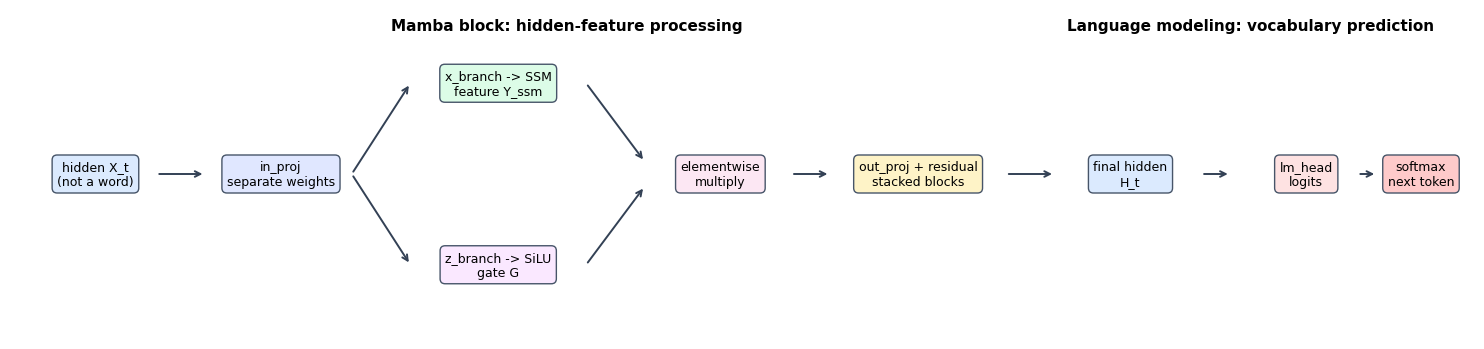

In [39]:
if HAS_MPL:
    # Mambaブロック内部のゲートと、モデル末尾の次単語予測を分けて図示します。
    fig, ax = plt.subplots(figsize=(15, 3.6))
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 4)
    ax.axis('off')

    def flow_box(x, y, text, color, width=1.55):
        ax.text(x + width / 2, y + 0.4, text, ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='#475569'))

    def flow_arrow(start, end, label=None):
        ax.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='->', color='#334155', linewidth=1.4))
        if label:
            ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.15,
                    label, ha='center', fontsize=8, color='#475569')

    flow_box(0.1, 1.6, 'hidden X_t\n(not a word)', '#dbeafe')
    flow_box(2.0, 1.6, 'in_proj\nseparate weights', '#e0e7ff')
    flow_box(4.1, 2.7, 'x_branch -> SSM\nfeature Y_ssm', '#dcfce7', 1.8)
    flow_box(4.1, 0.5, 'z_branch -> SiLU\ngate G', '#fae8ff', 1.8)
    flow_box(6.5, 1.6, 'elementwise\nmultiply', '#fce7f3')
    flow_box(8.4, 1.6, 'out_proj + residual\nstacked blocks', '#fef3c7', 1.8)
    flow_box(10.7, 1.6, 'final hidden\nH_t', '#dbeafe')
    flow_box(12.5, 1.6, 'lm_head\nlogits', '#fee2e2')
    flow_box(14.0, 1.6, 'softmax\nnext token', '#fecaca', 0.9)

    flow_arrow((1.5, 2.0), (2.0, 2.0))
    flow_arrow((3.5, 2.0), (4.1, 3.1))
    flow_arrow((3.5, 2.0), (4.1, 0.9))
    flow_arrow((5.9, 3.1), (6.5, 2.15))
    flow_arrow((5.9, 0.9), (6.5, 1.85))
    flow_arrow((8.0, 2.0), (8.4, 2.0))
    flow_arrow((10.2, 2.0), (10.7, 2.0))
    flow_arrow((12.2, 2.0), (12.5, 2.0))
    flow_arrow((13.8, 2.0), (14.0, 2.0))

    ax.text(5.7, 3.75, 'Mamba block: hidden-feature processing', ha='center',
            fontsize=11, fontweight='bold')
    ax.text(12.7, 3.75, 'Language modeling: vocabulary prediction', ha='center',
            fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Matplotlibがないため、隠れ特徴から次単語予測までの図をスキップします。')


## 2. 選択的SSMをNumPyで実装する

Mambaの中核は、入力ごとに異なるパラメータを使うSSMです。簡略化して1系列・多チャネルなしで書くと次の形です。

$$h_t = \bar{A}_t h_{t-1} + \bar{B}_t x_t$$

$$y_t = C_t h_t + D x_t$$

`A` は安定な連続時間パラメータ、`Delta_t` で離散化して `A_bar_t` を作ります。`B_t, C_t, Delta_t` は入力から作られるため時刻ごとに変わります。

In [40]:
def selective_scan_numpy(x, delta, A_log, B, C, D=None):
    """Understanding implementation of selective scan.

    Shapes:
        x:     (L, D)
        delta: (L, D)
        A_log: (D, N)
        B:     (L, N)
        C:     (L, N)
        D:     (D,)
    Returns:
        y:     (L, D)
    """
    L, d_model = x.shape
    d_state = A_log.shape[1]

    # Aは連続時間SSMの状態遷移。負にしておくと状態が発散しにくくなります。
    A = -np.exp(A_log)
    h = np.zeros((d_model, d_state))
    ys = []
    for t in range(L):
        # delta[t]で時刻t専用の離散化を行い、状態の残りやすさを決めます。
        A_bar = np.exp(delta[t, :, None] * A)

        # B[t]は入力x[t]を各状態次元へどれだけ書き込むかを決めます。
        B_bar_x = delta[t, :, None] * B[t][None, :] * x[t, :, None]

        # 前時刻の状態を減衰させつつ、現在の入力を書き込みます。
        h = A_bar * h + B_bar_x

        # C[t]は現在の状態からどの情報を読み出すかを決めます。
        y = np.sum(h * C[t][None, :], axis=1)
        if D is not None:
            # DはSSM状態を経由しない入力から出力へのスキップです。
            y = y + D * x[t]
        ys.append(y)
    return np.stack(ys)

def positive_softplus(x):
    """離散化幅deltaを正にするための、このセクション内だけのSoftplus実装。"""
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)


rng = np.random.default_rng(1)
L, d_model, d_state = 8, 3, 4
x = rng.normal(size=(L, d_model))
# Softplusを使い、離散化幅deltaを正に制約します。
delta = positive_softplus(rng.normal(size=(L, d_model)))
A_log = np.log(np.arange(1, d_state + 1, dtype=float))[None, :].repeat(d_model, axis=0)
B = rng.normal(size=(L, d_state))
C = rng.normal(size=(L, d_state))
D = np.ones(d_model) * 0.1

y = selective_scan_numpy(x, delta, A_log, B, C, D)
print('x shape:', x.shape)
print('output shape:', y.shape)
print(y[:3])


x shape: (8, 3)
output shape: (8, 3)
[[ 0.059  0.208  0.252]
 [ 0.049 -0.057  0.02 ]
 [ 0.855  0.204 -0.005]]


確認すべき点:

- `A` はチャネルごとに持つ固定の状態遷移です
- `delta[t]` は時刻ごとの離散化幅です
- `B[t]` は入力を状態へ書き込む係数です
- `C[t]` は状態から出力を読む係数です
- `B, C, delta` が時刻で変わるため、固定カーネル畳み込みにはできません

## 3. Mambaブロックの部品

理解用のMambaブロックは次の流れで作ります。

1. 入力 `x` を2本の経路 `x_branch, z_branch` に射影する
2. `x_branch` に短い因果Conv1dをかけ、局所パターンを混ぜる
3. Conv後の特徴から `delta, B, C` を作る
4. 選択的SSMで系列方向に情報を伝える
5. `z_branch` のゲートを掛ける
6. 出力射影で元の次元へ戻す

本物の実装では高速化とテンソル配置が重要ですが、ここでは形と意味が見える実装にします。

In [41]:
if HAS_TORCH:
    class RMSNorm(nn.Module):
        """各トークンの特徴ベクトルをRMSで正規化し、学習可能な重みを掛ける層。"""

        def __init__(self, dim, eps=1e-6):
            """特徴次元dimのRMSNormを作成する。epsは0除算を防ぐ定数。"""
            super().__init__()
            self.weight = nn.Parameter(torch.ones(dim))
            self.eps = eps

        def forward(self, x):
            """最後の特徴次元を正規化し、入力と同じ形状のテンソルを返す。"""
            # rsqrt(m)はm**(-1/2)です。ここでは1/RMSを直接計算します。
            mean_square = x.pow(2).mean(dim=-1, keepdim=True)
            inv_rms = torch.rsqrt(mean_square + self.eps)
            # x / RMS と x * (1 / RMS) は同じ計算です。
            return x * inv_rms * self.weight

    def selective_scan_torch(x, delta, A_log, B, C, D):
        """入力依存のdelta/B/Cを使い、系列を左から右へ走査してSSM出力を計算する。

        xとdeltaは(batch, length, d_inner)、戻り値も同じ形状。
        各時刻で状態hを更新し、Cで読み出した値にDによる入力スキップを加える。
        """
        # x, delta: (batch, length, d_inner)
        # A_log: (d_inner, d_state), B/C: (batch, length, d_state)
        batch, length, d_inner = x.shape
        d_state = A_log.shape[1]
        A = -torch.exp(A_log)
        h = x.new_zeros(batch, d_inner, d_state)
        ys = []
        for t in range(length):
            # 時刻tのdelta/B/Cを使って、全チャネルの状態をまとめて更新します。
            A_bar = torch.exp(delta[:, t, :, None] * A[None, :, :])
            B_bar_x = delta[:, t, :, None] * B[:, t, None, :] * x[:, t, :, None]
            h = A_bar * h + B_bar_x
            y = (h * C[:, t, None, :]).sum(dim=-1) + D * x[:, t]
            ys.append(y)
        return torch.stack(ys, dim=1)

    class MiniMambaBlock(nn.Module):
        """因果Conv、選択的SSM、zゲートを組み合わせた理解用Mambaブロック。"""

        def __init__(self, d_model, d_state=8, expand=2, conv_kernel=3, dt_rank=4):
            """モデル次元、状態次元、拡張率、Conv幅、Deltaのランクを指定して構築する。"""
            super().__init__()
            self.d_model = d_model
            self.d_inner = d_model * expand
            self.d_state = d_state

            # 入力をSSMへ入る経路(x)と、出力を制御するゲート経路(z)に分けます。
            self.in_proj = nn.Linear(d_model, 2 * self.d_inner)

            # depthwise causal conv: チャネルごとに現在と直近K-1個の入力を混ぜます。
            self.conv1d = nn.Conv1d(
                self.d_inner,
                self.d_inner,
                kernel_size=conv_kernel,
                groups=self.d_inner,  # 各チャネルに独立した畳み込みカーネルを適用
                padding=conv_kernel - 1,  # 系列先頭に必要なK-1個のゼロを確保
            )

            # Conv後の特徴から、選択的SSMに必要な入力依存パラメータを作ります。
            self.x_proj = nn.Linear(self.d_inner, dt_rank + 2 * d_state, bias=False)
            self.dt_proj = nn.Linear(dt_rank, self.d_inner)
            self.A_log = nn.Parameter(torch.log(torch.arange(1, d_state + 1).float()).repeat(self.d_inner, 1))
            self.D = nn.Parameter(torch.ones(self.d_inner))
            self.out_proj = nn.Linear(self.d_inner, d_model)

        @staticmethod
        def causal_depthwise_conv1d(x, conv1d):
            """(batch, length, channels)に因果depthwise畳み込みを適用する。"""
            length = x.shape[1]
            x_channels_first = x.transpose(1, 2)
            y = conv1d(x_channels_first)[:, :, :length]
            return y.transpose(1, 2)

        def forward(self, x, return_cache=False):
            """(batch, length, d_model)の隠れ特徴を処理する。

            通常は同形状のブロック出力を返す。return_cache=Trueでは、
            Deltaやゲートなどの観察用中間テンソルも辞書で返す。
            """
            batch, length, _ = x.shape
            xz = self.in_proj(x)
            x_branch, z_branch = xz.chunk(2, dim=-1)

            # ブロック内の実装で、未来を見ない局所混合を行います。
            conv_out = self.causal_depthwise_conv1d(x_branch, self.conv1d)
            scan_x = F.silu(conv_out)

            # dt_rawは低ランク表現で、dt_proj後に各チャネルのdeltaになります。
            params = self.x_proj(scan_x)
            dt_raw, B, C = torch.split(params, [self.dt_proj.in_features, self.d_state, self.d_state], dim=-1)
            # W_Deltaとb_Deltaで各内部チャネルへ展開した後、正の時間幅にします。
            delta_pre = self.dt_proj(dt_raw)
            delta = F.softplus(delta_pre)

            ssm_out = selective_scan_torch(scan_x, delta, self.A_log, B, C, self.D)

            # これは残差接続ではなく、入力から作った係数による要素単位のゲートです。
            gate = F.silu(z_branch)
            gated_out = ssm_out * gate
            out = self.out_proj(gated_out)
            if return_cache:
                return out, {
                    'x_branch': x_branch, 'z_branch': z_branch, 'scan_x': scan_x,
                    'delta': delta, 'B': B, 'C': C,
                    'ssm_out': ssm_out, 'gate': gate, 'gated_out': gated_out,
                }
            return out

    block = MiniMambaBlock(d_model=16, d_state=8)
    dummy = torch.randn(2, 10, 16)
    out, cache = block(dummy, return_cache=True)
    print('input :', tuple(dummy.shape))
    print('output:', tuple(out.shape))
    for k, v in cache.items():
        print(f'{k:>8}:', tuple(v.shape))
else:
    print('PyTorch is not installed. Install torch to run the Mamba block cells.')


input : (2, 10, 16)
output: (2, 10, 16)
x_branch: (2, 10, 32)
z_branch: (2, 10, 32)
  scan_x: (2, 10, 32)
   delta: (2, 10, 32)
       B: (2, 10, 8)
       C: (2, 10, 8)
 ssm_out: (2, 10, 32)
    gate: (2, 10, 32)
gated_out: (2, 10, 32)


## 4. ブロックを積む

Mambaのモデル全体は、正規化、Mambaブロック、残差接続を繰り返します。Transformerのattention層をMambaブロックに置き換えたと見るより、系列混合の中心が選択的SSMになったモデルとして見る方が構造を追いやすいです。

In [42]:
if HAS_TORCH:
    class MiniMambaLanguageModel(nn.Module):
        """Embeddingと複数のMambaブロックから、各位置の語彙logitを作る言語モデル。"""

        def __init__(self, vocab_size, d_model=64, n_layers=2, d_state=16):
            """語彙数、隠れ次元、層数、SSM状態次元を指定してモデルを構築する。"""
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, d_model)
            self.layers = nn.ModuleList([
                nn.ModuleDict({'norm': RMSNorm(d_model), 'mamba': MiniMambaBlock(d_model, d_state=d_state)})
                for _ in range(n_layers)
            ])
            self.norm_f = RMSNorm(d_model)
            self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        def forward(self, tokens):
            """(batch, length)のトークンIDを、(batch, length, vocab_size)のlogitへ変換する。"""
            # token idを連続ベクトルに変換します。
            x = self.embedding(tokens)
            for layer in self.layers:
                # pre-normしてMambaブロックに通し、残差接続で元の表現に足します。
                x = x + layer['mamba'](layer['norm'](x))
            return self.lm_head(self.norm_f(x))

    model = MiniMambaLanguageModel(vocab_size=20, d_model=32, n_layers=2, d_state=8)
    tokens = torch.randint(0, 20, (4, 12))
    logits = model(tokens)
    print('tokens:', tuple(tokens.shape))
    print('logits:', tuple(logits.shape))
    print('parameters:', sum(p.numel() for p in model.parameters()))
else:
    print('Skip: PyTorch is not installed.')


tokens: (4, 12)
logits: (4, 12, 20)
parameters: 18848


## 5. 小さなLLMタスク: 短い文章の「次の文字」を予測する

ここでは、よりLLMらしいタスクにします。モデルに短い文章を左から右へ読ませ、各位置で「次に来る文字」を予測させます。

例えば、入力が `mambaは` なら、次の文字として `系` や `長` など、学習データでよく続いた文字に高い確率を出すように学習します。

この教材では外部データセットは不要です。セル内に小さな文章コーパスを直接用意し、それを文字単位でID化します。実用的な言語モデルではありませんが、Embedding、Mambaブロック、出力headを使って「次トークン予測」を学習する流れは本物のLLMと同じです。


In [43]:
if HAS_TORCH:
    tiny_corpus = """
    mambaは系列データを左から右へ読む。
    mambaは長い文脈を効率よく扱う。
    言語モデルは次の文字を予測する。
    小さなモデルでも短い文章なら学習できる。
    入力の各位置から次の文字を当てる。
    embeddingは文字IDをベクトルに変える。
    mambaブロックは系列の情報を混ぜる。
    最後の線形層は次の文字のスコアを出す。
    lossが下がると予測が文章らしくなる。
    """
    tiny_corpus = "\n".join(line.strip() for line in tiny_corpus.strip().splitlines()) + "\n"
    chars = sorted(set(tiny_corpus))
    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for ch, i in stoi.items()}
    vocab_size = len(chars)

    def encode(text):
        """文字列を文字IDのリストへ変換する。"""
        return [stoi[ch] for ch in text]

    def decode(token_ids):
        """文字IDのリストを文字列へ戻す。"""
        return "".join(itos[int(i)] for i in token_ids)

    corpus_ids = torch.tensor(encode(tiny_corpus), dtype=torch.long)

    def make_text_batch(batch_size=32, block_size=32, device='cpu'):
        """次文字予測用の入力xと正解yを作る。

        xは長さblock_sizeの文字ID列、yはxを1文字だけ右へずらした正解列。
        つまり、y[:, t] は x[:, t] の次に来るべき文字IDになる。
        """
        if block_size >= len(corpus_ids):
            raise ValueError('block_size must be smaller than the corpus length')

        # startからblock_size文字を入力xにし、その1文字後ろを正解yにします。
        # torch.randintの上限は排他的なので、最後の有効開始位置も含めるため+1します。
        max_start = len(corpus_ids) - block_size - 1
        starts = torch.randint(0, max_start + 1, (batch_size,))
        x = torch.stack([corpus_ids[s:s + block_size] for s in starts]).to(device)
        y = torch.stack([corpus_ids[s + 1:s + block_size + 1] for s in starts]).to(device)
        return x, y

    xb, yb = make_text_batch(batch_size=2, block_size=24)
    print('vocab size:', vocab_size)
    print('corpus length:', len(corpus_ids))
    print('input example :', repr(decode(xb[0].tolist())))
    print('target example:', repr(decode(yb[0].tolist())))
    print('first 10 training pairs:')
    for current_id, next_id in zip(xb[0, :10].tolist(), yb[0, :10].tolist()):
        print(repr(itos[current_id]), '->', repr(itos[next_id]))
else:
    print('Skip: PyTorch is not installed.')


vocab size: 93
corpus length: 183
input example : '。\n小さなモデルでも短い文章なら学習できる。\n入'
target example: '\n小さなモデルでも短い文章なら学習できる。\n入力'
first 10 training pairs:
'。' -> '\n'
'\n' -> '小'
'小' -> 'さ'
'さ' -> 'な'
'な' -> 'モ'
'モ' -> 'デ'
'デ' -> 'ル'
'ル' -> 'で'
'で' -> 'も'
'も' -> '短'


In [44]:
if HAS_TORCH:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    block_size = 40
    model = MiniMambaLanguageModel(vocab_size=vocab_size, d_model=64, n_layers=2, d_state=16).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-3)

    losses, token_accs = [], []
    steps = 180
    start = time.time()
    for step in range(1, steps + 1):
        xb, yb = make_text_batch(batch_size=32, block_size=block_size, device=device)
        logits = model(xb)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            pred = logits.argmax(dim=-1)
            token_acc = (pred == yb).float().mean().item()
        losses.append(loss.item())
        token_accs.append(token_acc)
        if step % 30 == 0:
            print(f'step {step:03d} loss={loss.item():.3f} token_acc={token_acc:.3f}')

    print('elapsed sec:', round(time.time() - start, 1))
else:
    print('Skip: PyTorch is not installed.')


step 030 loss=0.285 token_acc=0.941
step 060 loss=0.072 token_acc=0.969
step 090 loss=0.063 token_acc=0.973
step 120 loss=0.053 token_acc=0.974
step 150 loss=0.046 token_acc=0.978
step 180 loss=0.044 token_acc=0.983
elapsed sec: 17.1


In [51]:
if HAS_TORCH:
    def generate_text(model, prompt, max_new_chars=40, temperature=0.8):
        """学習済みモデルで、promptの続きを1文字ずつ生成する。"""
        model.eval()
        token_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
        with torch.no_grad():
            for _ in range(max_new_chars):
                # 学習時と同じ長さを超えたら、直近block_size文字だけを文脈に使います。
                context = token_ids[:, -block_size:]
                logits = model(context)
                next_logits = logits[:, -1, :] / temperature
                probs = F.softmax(next_logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)
                token_ids = torch.cat([token_ids, next_id], dim=1)
        return decode(token_ids[0].cpu().tolist())

    prompt = 'mambaは'
    generated = generate_text(model, prompt, max_new_chars=35, temperature=0.7)
    print('prompt   :', repr(prompt))
    print('generated:', repr(generated))

    check_text = 'mambaは系列データを'
    check_ids = torch.tensor([encode(check_text)], dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(check_ids)
        predicted_ids = logits.argmax(dim=-1).squeeze(0).cpu().tolist()

    print('\nnext-character predictions:')
    for ch, pred_id in zip(check_text, predicted_ids):
        print(repr(ch), '->', repr(itos[pred_id]))
else:
    print('Skip: PyTorch is not installed.')


prompt   : 'mambaは'
generated: 'mambaは長い文脈を効率よく扱う。\n言語モデルは次の文字を予測する。\n小さなモデ'

next-character predictions:
'm' -> 'b'
'a' -> 'm'
'm' -> 'b'
'b' -> 'a'
'a' -> 'ブ'
'は' -> '長'
'系' -> '列'
'列' -> 'デ'
'デ' -> 'ー'
'ー' -> 'タ'
'タ' -> 'を'
'を' -> '左'


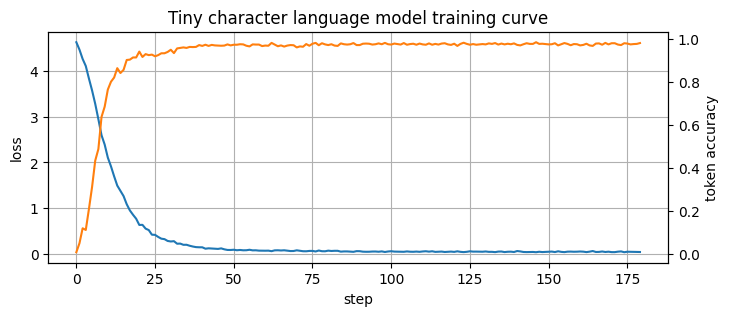

In [50]:
if HAS_TORCH and HAS_MPL:
    fig, ax1 = plt.subplots(figsize=(8, 3))
    ax1.plot(losses, label='loss')
    ax1.set_xlabel('step')
    ax1.set_ylabel('loss')
    ax2 = ax1.twinx()
    ax2.plot(token_accs, color='tab:orange', label='token accuracy')
    ax2.set_ylabel('token accuracy')
    ax1.grid(True)
    plt.title('Tiny character language model training curve')
    plt.show()
elif HAS_TORCH:
    print('last loss:', losses[-1], 'last token acc:', token_accs[-1])
else:
    print('Skip: PyTorch is not installed.')


## 6. `Delta` を観察する

学習済みモデルの最初のMambaブロックから `delta` を取り出します。ここでは、短い文章を入力したとき、位置ごとにMamba内部の時間スケールがどう変わるかを眺めます。

`delta` は「この位置を重要視している度合い」そのものではありません。ただし、入力文字に応じて状態更新の仕方が変わる、という選択的SSMの特徴を確認できます。


input text: mambaは系列データを左から右へ読む。
greedy next-char prediction:
'm' -> 'b'
'a' -> 'm'
'm' -> 'b'
'b' -> 'a'
'a' -> 'ブ'
'は' -> '長'
'系' -> '列'
'列' -> 'デ'
'デ' -> 'ー'
'ー' -> 'タ'
'タ' -> 'を'
'を' -> '左'
'左' -> 'か'
'か' -> 'ら'
'ら' -> '右'
'右' -> 'へ'
'へ' -> '読'
'読' -> 'む'
'む' -> '。'
'。' -> '\n'
delta mean: [0.744 0.734 0.749 0.719 0.747 0.732 0.72  0.725 0.747 0.725 0.729 0.734
 0.749 0.744 0.719 0.735 0.735 0.724 0.734 0.73 ]


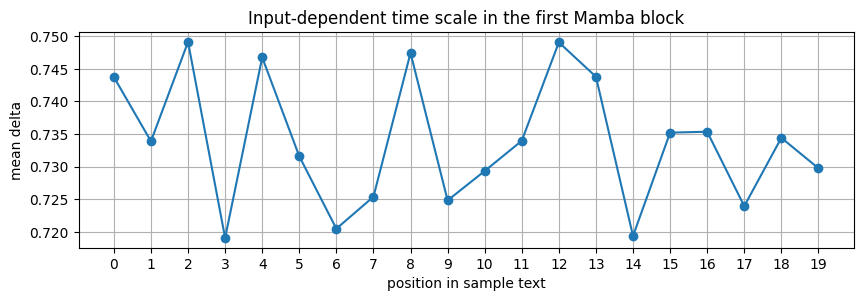

In [52]:
if HAS_TORCH:
    model.eval()
    sample_text = 'mambaは系列データを左から右へ読む。'
    sample_ids = torch.tensor([encode(sample_text)], dtype=torch.long, device=device)
    with torch.no_grad():
        x_embed = model.embedding(sample_ids)
        first = model.layers[0]
        _, cache = first['mamba'](first['norm'](x_embed), return_cache=True)
        delta_mean = cache['delta'].mean(dim=-1).squeeze(0).cpu().numpy()
        logits = model(sample_ids)
        next_ids = logits.argmax(dim=-1).squeeze(0).cpu().tolist()

    print('input text:', sample_text)
    print('greedy next-char prediction:')
    for ch, next_id in zip(sample_text, next_ids):
        print(repr(ch), '->', repr(itos[next_id]))
    print('delta mean:', np.round(delta_mean, 3))

    if HAS_MPL:
        plt.figure(figsize=(10, 2.8))
        plt.plot(delta_mean, marker='o')
        # 日本語文字をtick labelにすると、環境によってはフォント警告が大量に出ます。
        # 図では位置番号だけを表示し、文字そのものは上のprint出力で確認します。
        plt.xticks(range(len(sample_text)))
        plt.xlabel('position in sample text')
        plt.ylabel('mean delta')
        plt.title('Input-dependent time scale in the first Mamba block')
        plt.grid(True)
        plt.show()
else:
    print('Skip: PyTorch is not installed.')


## 7. 計算量の直感

自己注意は長さ `L` に対して全ペアを比較するため、典型的には `O(L^2)` の注意行列を扱います。一方、再帰型SSMは各時刻で状態を1回更新するため `O(L)` です。

Mambaでは `B, C, Delta` が入力依存なので、S4のような固定畳み込みには戻せません。その代わり、論文と公式実装ではハードウェアを意識したスキャンで高速化します。この教材のPythonループ実装は理解用であり、速度比較用ではありません。

 length | attention L^2 | ssm L
    128 |         16384 |   128
    256 |         65536 |   256
    512 |        262144 |   512
   1024 |       1048576 |  1024
   2048 |       4194304 |  2048
   4096 |      16777216 |  4096


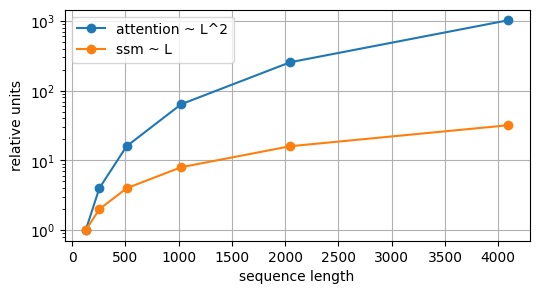

In [53]:
lengths = np.array([128, 256, 512, 1024, 2048, 4096])
attention_units = lengths ** 2
ssm_units = lengths
table = np.stack([lengths, attention_units, ssm_units], axis=1)
print(' length | attention L^2 | ssm L')
for L, a, s in table:
    print(f'{L:7d} | {a:13d} | {s:5d}')

if HAS_MPL:
    plt.figure(figsize=(6, 3))
    plt.plot(lengths, attention_units / attention_units[0], marker='o', label='attention ~ L^2')
    plt.plot(lengths, ssm_units / ssm_units[0], marker='o', label='ssm ~ L')
    plt.yscale('log')
    plt.xlabel('sequence length')
    plt.ylabel('relative units')
    plt.grid(True)
    plt.legend()
    plt.show()

## 8. アーキテクチャ理解チェック

次の問いに答えられれば、Mambaの構造はかなり見えています。

1. 通常の時不変SSMと、Mambaの選択的SSMは何が違いますか。
2. `Delta_t` は状態更新にどのような影響を与えますか。
3. `B_t` と `C_t` を入力から作る意味は何ですか。
4. depthwise causal convolutionは、選択的SSMの前で何を混ぜていますか。
5. `z_branch` のゲートはブロック内でどの役割を持ちますか。
6. Mambaが長系列で有利になりやすい理由を、計算量と推論状態の観点から説明してください。
7. この教材の実装と公式実装の違いは何ですか。特に速度最適化について説明してください。

## 9. 発展課題

- `d_state` を変え、合成タスクの学習速度と最終精度を比較してください。
- 系列長を `32, 64, 128` に変え、保持が難しくなるか確認してください。
- `MiniMambaBlock` からConv1dを外し、局所混合がない場合の性能を比べてください。
- `delta` の平均だけでなく、チャネルごとのヒートマップを表示してください。
- 公式リポジトリの `mamba_simple.py` とこの実装を見比べ、どのテンソルが対応するか対応表を作ってください。